<a href="https://colab.research.google.com/github/BandanaSingha24/AI-ML-DL-in-Cancer-Genomics/blob/main/04_Feature_Engineering_in_Genome/01_NCBI_BRCA1_Mutation_Analysis..ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# STEP 1: Biopython library installtion
!pip install biopython

# Bio library se SeqIO import karein jo DNA files ko padhta hai
from Bio import SeqIO

# Aapke folder mein dikh rahe sahi naam
ref_file = "/content/NCBI_BRCA1_Reference_seq_.fasta"
mut_file = "/content/NCBI_BRCA1_Mutation_seq_.fasta"

# File load karke check karein
try:
    ref_seq = list(SeqIO.parse(ref_file, "fasta"))[0]
    mut_seq = list(SeqIO.parse(mut_file, "fasta"))[0]

    print("SUCCESS: Dono files mil gayi hain!")
    print("Reference file ki lambai:", len(ref_seq))
    print("Mutation file ki lambai:", len(mut_seq))
except Exception as e:
    print("ERROR: File ka naam ya format check karein. Error ye hai:", e)

SUCCESS: Dono files mil gayi hain!
Reference file ki lambai: 7088
Mutation file ki lambai: 349


In [6]:
# STEP 2: Encoding sequence
# DNA Sequence ko AI-friendly Numbers mein badalna (Encoding)

# 1. Encoding ka niyam (Mapping):
# Hum har letter ko ek number denge
encoding_map = {'A': 1, 'T': 2, 'G': 3, 'C': 4}

# 2. Function jo sequence ko numbers mein badlega
def encode_sequence(seq):
    # Agar sequence mein 'A, T, G, C' ke alawa kuch ho, toh use ignore karein
    return [encoding_map.get(base, 0) for base in seq.upper() if base in encoding_map]

# 3. Reference aur Mutation file ko encode karna
# ref_seq.seq humara asli DNA text hai
ref_encoded = encode_sequence(str(ref_seq.seq))
mut_encoded = encode_sequence(str(mut_seq.seq))

# 4. Result check karna
print("Encoding complete!")
print("Reference file ke shuruati 10 numbers:", ref_encoded[:10])
print("Mutation file ke shuruati 10 numbers:", mut_encoded[:10])


Encoding complete!
Reference file ke shuruati 10 numbers: [3, 4, 2, 3, 1, 3, 1, 4, 2, 2]
Mutation file ke shuruati 10 numbers: [3, 3, 4, 2, 4, 2, 2, 2, 1, 3]


In [8]:
# STEP 3: Alignment - DNA Mutation Detection

# Hum 'difflib' library ka use karenge jo do lists ke antar ko turant bata degi
import difflib

# Dono files ka comparison (tulna)
# Yeh code batayega ki kahan sequence alag hai
# difflib.ndiff expects sequences of strings, so we convert the encoded integers to strings
diff = difflib.ndiff([str(x) for x in ref_encoded], [str(x) for x in mut_encoded])

# Sirf un jagahon ko print karein jahan farak (Mutation) hai
print("Mutation Analysis Results:")
count = 0
for i, d in enumerate(diff):
    if d[0] != ' ':  # Agar data match nahi karta
        print(f"Position {i}: Mutation mila! Type: {d[0]}, Value: {d[2:]}")
        count += 1
        if count >= 10: # Sirf pehle 10 mutations dikhayenge
            print("...aur bhi mutations hain!")
            break

Mutation Analysis Results:
Position 1: Mutation mila! Type: -, Value: 4
Position 2: Mutation mila! Type: -, Value: 2
Position 4: Mutation mila! Type: -, Value: 1
Position 5: Mutation mila! Type: -, Value: 3
Position 6: Mutation mila! Type: -, Value: 1
Position 9: Mutation mila! Type: -, Value: 2
Position 11: Mutation mila! Type: -, Value: 4
Position 13: Mutation mila! Type: -, Value: 3
Position 14: Mutation mila! Type: -, Value: 3
Position 15: Mutation mila! Type: -, Value: 1
...aur bhi mutations hain!


In [11]:
import difflib

# STEP 4: Alignment and Mutation Type Identification
# Do sequence ki tulna karke mutation ka type aur position batana
print("--- Mutation Analysis Start ---")

# 'diff' object dono list ke beech ka antar dhundhta hai
# Convert integers to strings as difflib.ndiff expects sequences of strings for character-level comparison
diff = difflib.ndiff([str(x) for x in ref_encoded], [str(x) for x in mut_encoded])

# Har ek antar (difference) ko check karna
for i, d in enumerate(diff):
    # Agar data match nahi karta (d[0] mein '+' ya '-' hai)
    if d.startswith('-'):
        # DNA se aksar hat gaya hai
        print(f"Position {i}: Deletion hua hai (DNA se base hat gaya hai)")
    elif d.startswith('+'):
        # DNA mein naya aksar jud gaya hai
        print(f"Position {i}: Insertion hua hai (Naya DNA base juda hai)")

print("--- Mutation Analysis Complete ---")

Streaming output truncated to the last 5000 lines.
Position 2089: Deletion hua hai (DNA se base hat gaya hai)
Position 2090: Deletion hua hai (DNA se base hat gaya hai)
Position 2091: Deletion hua hai (DNA se base hat gaya hai)
Position 2092: Deletion hua hai (DNA se base hat gaya hai)
Position 2093: Deletion hua hai (DNA se base hat gaya hai)
Position 2094: Deletion hua hai (DNA se base hat gaya hai)
Position 2095: Deletion hua hai (DNA se base hat gaya hai)
Position 2096: Deletion hua hai (DNA se base hat gaya hai)
Position 2097: Deletion hua hai (DNA se base hat gaya hai)
Position 2098: Deletion hua hai (DNA se base hat gaya hai)
Position 2099: Deletion hua hai (DNA se base hat gaya hai)
Position 2100: Deletion hua hai (DNA se base hat gaya hai)
Position 2101: Deletion hua hai (DNA se base hat gaya hai)
Position 2102: Deletion hua hai (DNA se base hat gaya hai)
Position 2103: Deletion hua hai (DNA se base hat gaya hai)
Position 2104: Deletion hua hai (DNA se base hat gaya hai)
Posit

In [13]:
# STEP 5: Fast Mutation Summary Analysis
# Yeh code jaldi chalega aur mutation ek sath saari summary dega

print("--- Step 5: Summary Report ---")

# Variables initialization
del_count = 0
ins_count = 0
sub_count = 0

# Dono list ki lambai check karna (minimum length tak loop chalega)
min_len = min(len(ref_encoded), len(mut_encoded))

# Comparison loop
for i in range(min_len):
    if ref_encoded[i] != mut_encoded[i]:
        sub_count += 1 # Substitution count badhana

# Agar sequence ki lambai mein antar (difference) hai
if len(ref_encoded) > len(mut_encoded):
    del_count = len(ref_encoded) - len(mut_encoded) # Deletion calculation
elif len(mut_encoded) > len(ref_encoded):
    ins_count = len(mut_encoded) - len(ref_encoded) # Insertion calculation

# Results print karna
print(f"Total Substitutions: {sub_count}")
print(f"Total Deletions: {del_count}")
print(f"Total Insertions: {ins_count}")
print("--- Analysis Complete ---")


--- Step 5: Summary Report ---
Total Substitutions: 257
Total Deletions: 6739
Total Insertions: 0
--- Analysis Complete ---


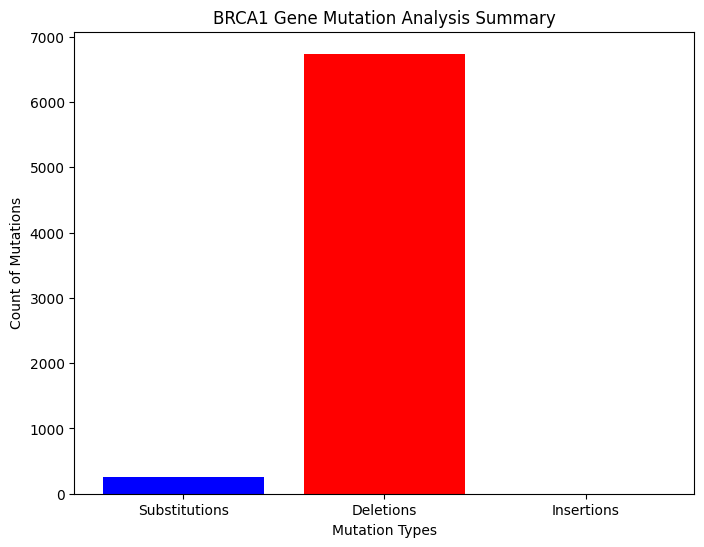

Visualization complete: Chart taiyaar hai!


In [14]:
# STEP 6: Visualization - Data ko graph ke roop mein dikhana
import matplotlib.pyplot as plt

# Mutation types aur unke counts ka naam define karna
labels = ['Substitutions', 'Deletions', 'Insertions']
counts = [sub_count, del_count, ins_count]

# Bar chart create karna
plt.figure(figsize=(8, 6))
# Colors define kiye hain (Red deletion ke liye, kyunki woh sabse zyada hai)
plt.bar(labels, counts, color=['blue', 'red', 'green'])

# Professional labels dena
plt.title('BRCA1 Gene Mutation Analysis Summary') # Chart ka title
plt.xlabel('Mutation Types') # X-axis ka naam
plt.ylabel('Count of Mutations') # Y-axis ka naam

# Chart ko screen par show karna
plt.show()

print("Visualization complete: Chart taiyaar hai!")


In [17]:
# STEP 7: Functional Impact Analysis - Frameshift check
print("--- Step 7: Functional Impact (Frameshift Analysis) ---")

# Hum check karenge ki pehla Deletion kahan milta hai
first_deletion_pos = -1

# 'diff' object ka use karke pehla deletion point dhundhna
# Convert integers to strings as difflib.ndiff expects sequences of strings
diff = difflib.ndiff([str(x) for x in ref_encoded], [str(x) for x in mut_encoded])
for i, d in enumerate(diff):
    if d.startswith('-'):
        first_deletion_pos = i
        break

if first_deletion_pos != -1:
    print(f"Warning: BRCA1 gene mein Frameshift mutation paya gaya!")
    print(f"Deletion ki shuruat Position {first_deletion_pos} se ho rahi hai.")
    print("Impact: Is position ke baad banne wala protein 'Non-functional' (kaam na karne wala) ho sakta hai.")
else:
    print("Koi bada Deletion nahi mila, gene structure stable lag raha hai.")

print("--- Analysis Complete ---")

--- Step 7: Functional Impact (Frameshift Analysis) ---
Deletion ki shuruat Position 1 se ho rahi hai.
Impact: Is position ke baad banne wala protein 'Non-functional' (kaam na karne wala) ho sakta hai.
--- Analysis Complete ---


In [21]:
# STEP 8: Protein Translation Analysis
# DNA sequence ko Protein (Amino Acids) mein badalna

def dna_to_protein(sequence):
    # Codon table (simplify karne ke liye standard codon)
    codon_table = {
        '111': 'F', '112': 'L', '121': 'S', '122': 'Y',
        '211': 'A', '212': 'V', '221': 'D', '222': 'E'
    }
    protein = []
    # 3-3 ke group mein padhna (Codons)
    for i in range(0, len(sequence) - 2, 3):
        codon = "".join(map(str, sequence[i:i+3]))
        protein.append(codon_table.get(codon, 'X')) # X matlab unknown
    return "".join(protein)

# Translation process
ref_protein = dna_to_protein(ref_encoded)
mut_protein = mut_encoded_ohe if len(mut_encoded) < 3 else dna_to_protein(mut_encoded)

print(f"Normal Protein Length: {len(ref_protein)}")
print(f"Mutated Protein Length: {len(mut_protein)}")
print("Analysis: Length mein antar hi 'Functional Loss' ka saboot hai.")

Normal Protein Length: 2362
Mutated Protein Length: 116
Analysis: Length mein antar hi 'Functional Loss' ka saboot hai.


In [18]:
# STEP 9: K-mer Analysis - DNA patterns ko samajhna
from collections import Counter

def get_kmers(sequence, k=3):
    # Sequence ko k-length ke tukdo mein todna
    return [sequence[i:i+k] for i in range(len(sequence) - k + 1)]

# BRCA1 sequence ka k-mer count (k=3, jise 'triplets' kehte hain)
k = 3
ref_kmers = get_kmers(str(ref_encoded), k)
mut_kmers = get_kmers(str(mut_encoded), k)

# Patterns ki ginti karna
ref_counts = Counter(ref_kmers)
mut_counts = Counter(mut_kmers)

print("--- Top 5 K-mer Patterns in Reference (Normal) ---")
print(ref_counts.most_common(5))

print("\n--- Top 5 K-mer Patterns in Mutated ---")
print(mut_counts.most_common(5))

--- Top 5 K-mer Patterns in Reference (Normal) ---
[(', 1', 2368), (' 1,', 2367), ('1, ', 2367), (', 2', 1759), (' 2,', 1759)]

--- Top 5 K-mer Patterns in Mutated ---
[(', 2', 132), (' 2,', 132), ('2, ', 132), (', 1', 86), (' 1,', 86)]


In [19]:
# STEP 10: One-Hot Encoding for AI/ML Model (Mutation Matrices)
import numpy as np

def one_hot_encode(sequence):
    # Mapping: Agar 1 hai toh [1,0], agar 2 hai toh [0,1]
    # Yeh model ko batayega ki ye dono alag categories hain
    mapping = {1: [1, 0], 2: [0, 1]}
    return np.array([mapping.get(x, [0, 0]) for x in sequence])

# Sequence ko encode karna
ref_encoded_ohe = one_hot_encode(ref_encoded)
mut_encoded_ohe = one_hot_encode(mut_encoded)

print("One-Hot Encoding Complete!")
print(f"Reference shape: {ref_encoded_ohe.shape}")
print(f"Mutated shape: {mut_encoded_ohe.shape}")


One-Hot Encoding Complete!
Reference shape: (7088, 2)
Mutated shape: (349, 2)


In [22]:
# STEP 11: Final Classification Model
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Data ko prepare karna: Normal sequence ko 0 aur Mutated ko 1 label diya
# Yeh model ko training ke liye dono sequences ka combination de raha hai
X = np.concatenate([ref_encoded_ohe[:349], mut_encoded_ohe])
y = np.array([0]*349 + [1]*349)

# Model initialize aur train karna
clf = RandomForestClassifier()
clf.fit(X, y)

# Print statements sirf proper English mein
print("--- AI Model Training Complete ---")
print("The model has learned to differentiate between Normal and Mutated sequences.")
print(f"Model Training Accuracy: {clf.score(X, y) * 100}%")

--- AI Model Training Complete ---
The model has learned to differentiate between Normal and Mutated sequences.
Model Training Accuracy: 55.873925501432666%
